<a href="https://colab.research.google.com/github/jovajara/pulsar-AI-project/blob/main/Pulsar_IA_proyect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IA proyect - Púlsar.




# Importar paquetes

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, ConfusionMatrixDisplay,confusion_matrix,classification_report
from sklearn.metrics import roc_curve, precision_recall_curve
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.inspection import DecisionBoundaryDisplay

from sklearn.ensemble import RandomForestClassifier

# Carga y limpieza del dataset desde github


El dataset HTRU2 se carga desde un archivo `.arff` usando `scipy.io.arff.loadarff`. Este formato almacena los valores categoricos (class) como bytes de Python (`b'0'`, `b'1'`), por lo que es necesario decodificarlos a enteros antes de continuar

Sin esta transformación, scikit-learn no podría operar correctamente con la columna target, ya que espera valores numéricos (0 y 1) y no objetos de tipo bytes

In [ ]:
# Load dataset

!git clone https://github.com/jovajara/pulsar-AI-project
%cd pulsar-AI-project

from scipy.io.arff import loadarff

raw_data = loadarff('HTRU_2.arff')
df_data = pd.DataFrame(raw_data[0])
df_data['class'] = df_data['class'].apply(lambda x: int(x.decode('utf-8')))

Cloning into 'pulsar-AI-project'...
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 10 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (10/10), 764.71 KiB | 4.87 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/pulsar-AI-project/pulsar-AI-project


In [ ]:
# Show dataset
df_data


,Profile_mean,Profile_stdev,Profile_skewness,Profile_kurtosis,DM_mean,DM_stdev,DM_skewness,DM_kurtosis,class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0
...,...,...,...,...,...,...,...,...,...
17893,136.429688,59.847421,-0.187846,-0.738123,1.296823,12.166062,15.450260,285.931022,0
17894,122.554688,49.485605,0.127978,0.323061,16.409699,44.626893,2.945244,8.297092,0
17895,119.335938,59.935939,0.159363,-0.743025,21.430602,58.872000,2.499517,4.595173,0
17896,114.507812,53.902400,0.201161,-0.024789,1.946488,13.381731,10.007967,134.238910,0


# Exploración inicial



In [ ]:
# === 02. Exploración inicial ===

print("Shape:", df_data.shape)
print()

# Tipos de datos
print("Tipos de datos:")
print(df_data.dtypes)
print()

# Valores faltantes
print("Valores faltantes por columna:")
print(df_data.isna().sum())
print()

# Duplicados
print("Filas duplicadas:", df_data.duplicated().sum())
print()

# Balance de clases
print("Distribución de clases:")
for k in [0, 1]:
    label = "No púlsar" if k == 0 else "Púlsar"
    count = (df_data['class'] == k).sum()
    prop = count / len(df_data) * 100
    print(f"  Clase {k} ({label}): {count:>5d}  ({prop:.2f} %)")

imbalance = (df_data['class'] == 0).sum() / (df_data['class'] == 1).sum()
print(f"\nRazón de desbalance: {imbalance:.2f}:1")
print()



Shape: (17898, 9)

Tipos de datos:
Profile_mean        float64
Profile_stdev       float64
Profile_skewness    float64
Profile_kurtosis    float64
DM_mean             float64
DM_stdev            float64
DM_skewness         float64
DM_kurtosis         float64
class                 int64
dtype: object

Valores faltantes por columna:
Profile_mean        0
Profile_stdev       0
Profile_skewness    0
Profile_kurtosis    0
DM_mean             0
DM_stdev            0
DM_skewness         0
DM_kurtosis         0
class               0
dtype: int64

Filas duplicadas: 0

Distribución de clases:
  Clase 0 (No púlsar): 16259  (90.84 %)
  Clase 1 (Púlsar):  1639  (9.16 %)

Razón de desbalance: 9.92:1



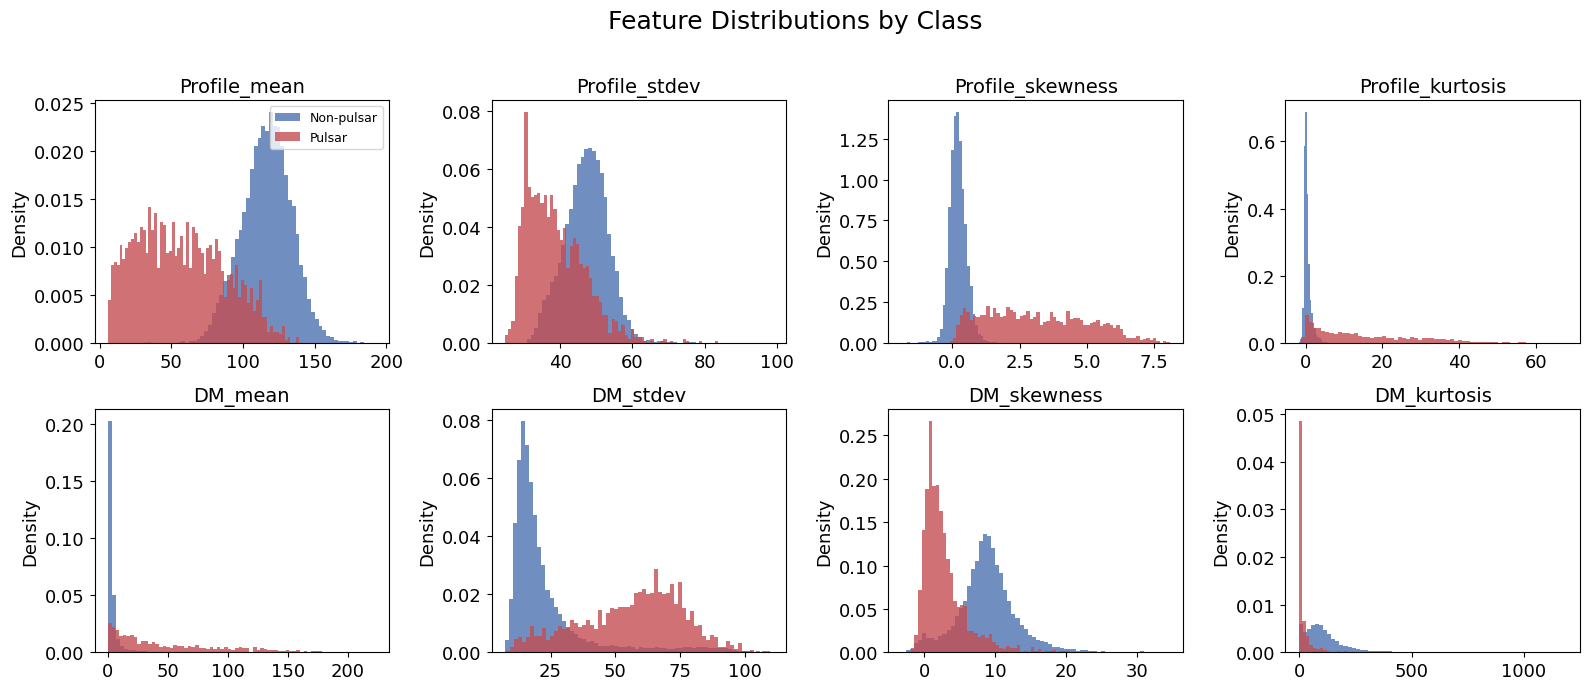

In [ ]:
# === 03. Análisis univariado ===

features = [col for col in df_data.columns if col != 'class']

# Histogramas por clase

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for ax, feat in zip(axes.flat, features):
    for cls, color, label in [(0, '#4C72B0', 'Non-pulsar'),
                              (1, '#C44E52', 'Pulsar')]:
        ax.hist(
            df_data.loc[df_data['class'] == cls, feat],
            bins=66, density=True, alpha=0.8,
            color=color, label=label
        )

    ax.set_title(feat, fontsize=14)
    ax.set_ylabel('Density', fontsize=13)
    ax.tick_params(axis='both', labelsize=13)

# Leyenda global (mejor que repetir en cada subplot)
handles, labels = axes[0,0].get_legend_handles_labels()
axes[0, 0].legend(loc='upper right', fontsize=9)

fig.suptitle(
    'Feature Distributions by Class\n',
    fontsize=18
)

fig.tight_layout()
plt.show()


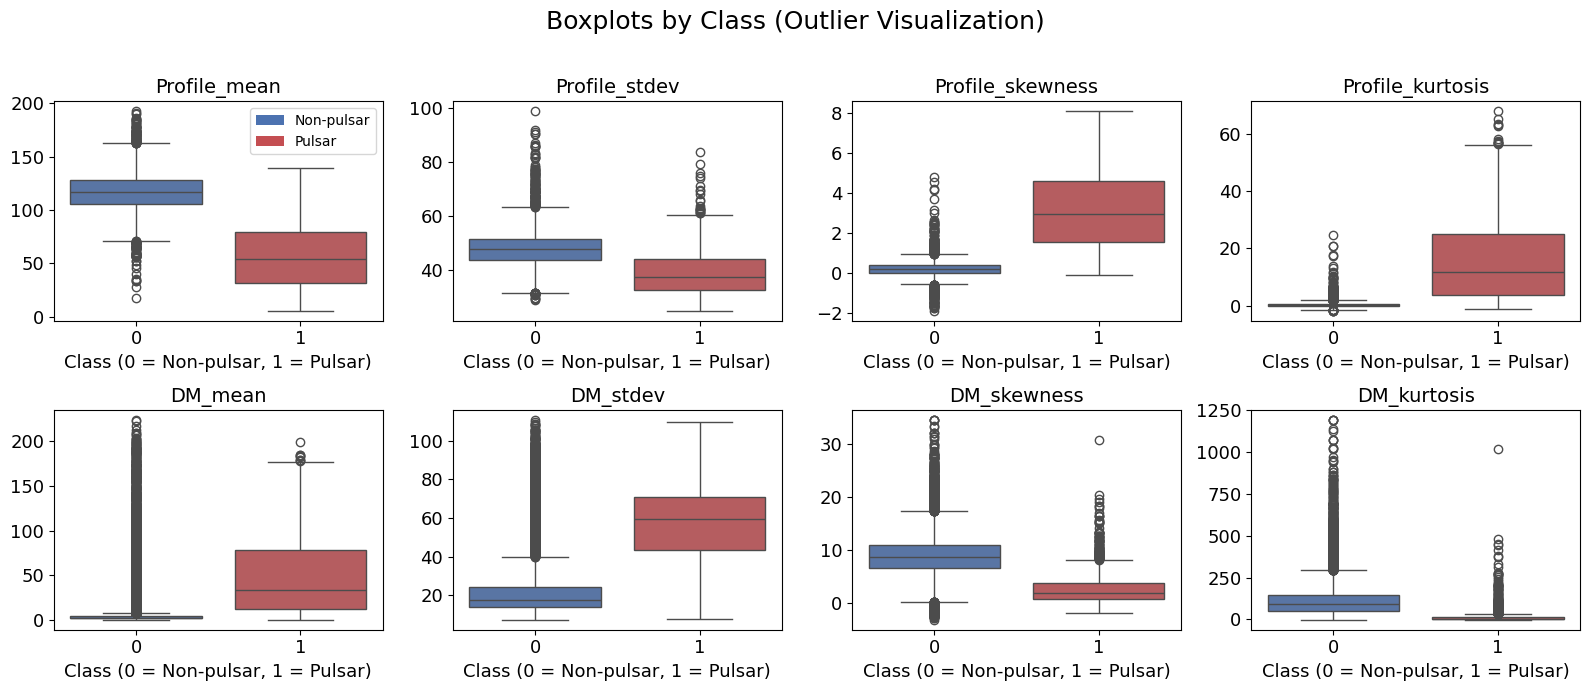

In [ ]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for ax, feat in zip(axes.flat, features):
    sns.boxplot(
        data=df_data,
        x='class', y=feat, ax=ax,
        hue='class',
        palette={0: '#4C72B0', 1: '#C44E52'}
    )
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    ax.set_title(feat, fontsize=14)
    ax.set_xlabel('Class (0 = Non-pulsar, 1 = Pulsar)', fontsize=13)
    ax.set_ylabel('')
    ax.tick_params(axis='both', labelsize=13)

legend_elements = [
    Patch(facecolor='#4C72B0', label='Non-pulsar'),
    Patch(facecolor='#C44E52', label='Pulsar')
]


axes[0,0].legend(
    handles=legend_elements,
    loc='upper right',
    fontsize=10
)

fig.suptitle(
    'Boxplots by Class (Outlier Visualization)\n', fontsize=18
)

fig.tight_layout()
plt.show()



## Interpretación del análisis univariado

### Histogramas

Las distribuciones separadas por clase revelan qué features tienen mayor poder discriminativo:

- **`Profile_mean`**: los púlsares tienen media más baja (~ 50) que los no-púlsares (~ 120). Esto es porque el pulso ocupa una fracción pequeña del periodo de rotación — al promediar, el perfil queda dominado por el "silencio" entre pulsos.
- **`Profile_skewness` y `Profile_kurtosis`**: muestran la separación más clara. Los púlsares tienen skewness y kurtosis significativamente más altas, reflejando un perfil con un pico estrecho y asimétrico (el pulso) sobre un fondo plano. Los no-púlsares se concentran cerca de cero (distribución gaussiana, sin pico).
- **`Profile_stdev`**: solapamiento considerable entre clases — la dispersión del perfil no distingue bien por sí sola.
- **`DM_mean` y `DM_stdev`**: los púlsares tienden a valores más altos, indicando un pico de SNR más fuerte a una DM específica.
- **`DM_skewness` y `DM_kurtosis`**: hay separación pero con colas extremas. Los no-púlsares se concentran en valores bajos mientras los púlsares se extienden más.

### Boxplots

Confirman las mismas observaciones y además revelan la presencia de **outliers extremos**:

- **`DM_kurtosis`**: valores que superan 1000 en ambas clases.
- **`DM_skewness`**: outliers por encima de 30.
- **`Profile_kurtosis`**: algunos valores alcanzan ~70.

Estos outliers **no se eliminan** porque no son errores de medición: corresponden a candidatos con picos de señal excepcionalmente pronunciados, que pueden ser púlsares fuertes o interferencia RFI muy localizada. Eliminarlos sesgaría el clasificador contra los casos más interesantes.

# Matriz de correlación

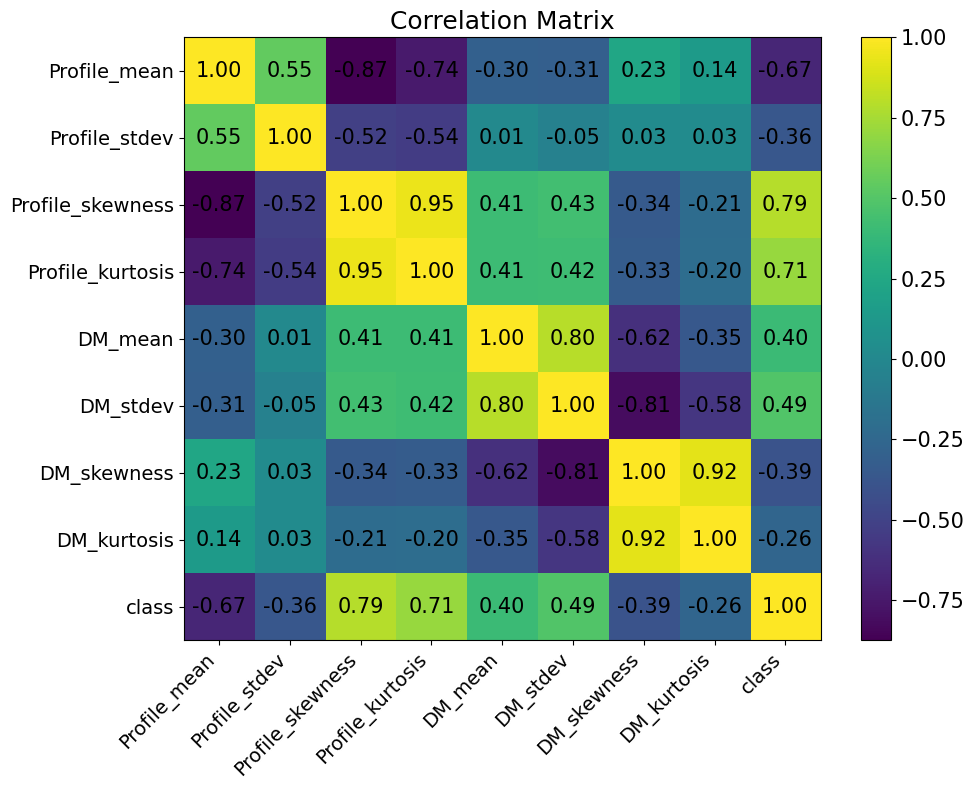

Correlation with target (sorted by absolute value):
Profile_skewness    0.792
Profile_kurtosis    0.710
Profile_mean       -0.673
DM_stdev            0.492
DM_mean             0.401
DM_skewness        -0.391
Profile_stdev      -0.364
DM_kurtosis        -0.259
Name: class, dtype: float64


In [ ]:
corr = df_data.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, aspect="auto")

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))

ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=14)
ax.set_yticklabels(corr.columns, fontsize=14)

ax.set_title("Correlation Matrix", fontsize=18)

# Add values inside cells
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.values[i, j]:.2f}",
                ha="center", va="center", fontsize=15)

cbar = fig.colorbar(im, ax=ax)
cbar.ax.tick_params(labelsize=15)

plt.tight_layout()
plt.show()

# Correlation with target
print("Correlation with target (sorted by absolute value):")
print(corr['class'].drop('class').sort_values(key=abs, ascending=False).round(3))


## Interpretación de la matriz de correlación

La matriz de correlación de Pearson revela tres patrones clave:

**1. Features más correlacionadas con el target (última fila/columna):**
- `Profile_skewness` (0.79) y `Profile_kurtosis` (0.71): correlación positiva más fuerte — valores altos → mayor probabilidad de ser púlsar.
- `Profile_mean` (−0.67): correlación negativa fuerte — valores bajos → mayor probabilidad de ser púlsar.
- `DM_stdev` (0.49) y `DM_mean` (0.40): correlación positiva moderada.
- `Profile_stdev` (−0.36), `DM_skewness` (−0.39), `DM_kurtosis` (−0.26): correlaciones más débiles.

**2. Correlaciones intra-bloque fuertes (redundancia):**
- `Profile_skewness` ↔ `Profile_kurtosis`: r = 0.95 (muy alta)
- `Profile_mean` ↔ `Profile_skewness`: r = −0.87
- `DM_skewness` ↔ `DM_kurtosis`: r = 0.92
- `DM_mean` ↔ `DM_stdev`: r = 0.80

Estas correlaciones altas son esperadas: la skewness y la kurtosis son el 3er y 4to momento de la misma distribución, por lo que naturalmente covarían. Esto introduce **multicolinealidad**, pero con solo 8 features no es un problema — la regularización L2 (LR) y el bagging (RF) la manejan bien.

**3. Correlaciones cross-bloque débiles (información complementaria):**
Las correlaciones entre features del perfil integrado y features de la curva DM-SNR son mayormente débiles (|r| < 0.45). Esto significa que los dos grupos de features capturan **aspectos distintos** de la señal: el perfil describe la forma del pulso, mientras que la curva DM-SNR describe el comportamiento de dispersión. Ambos aportan información útil y no redundante al clasificador.

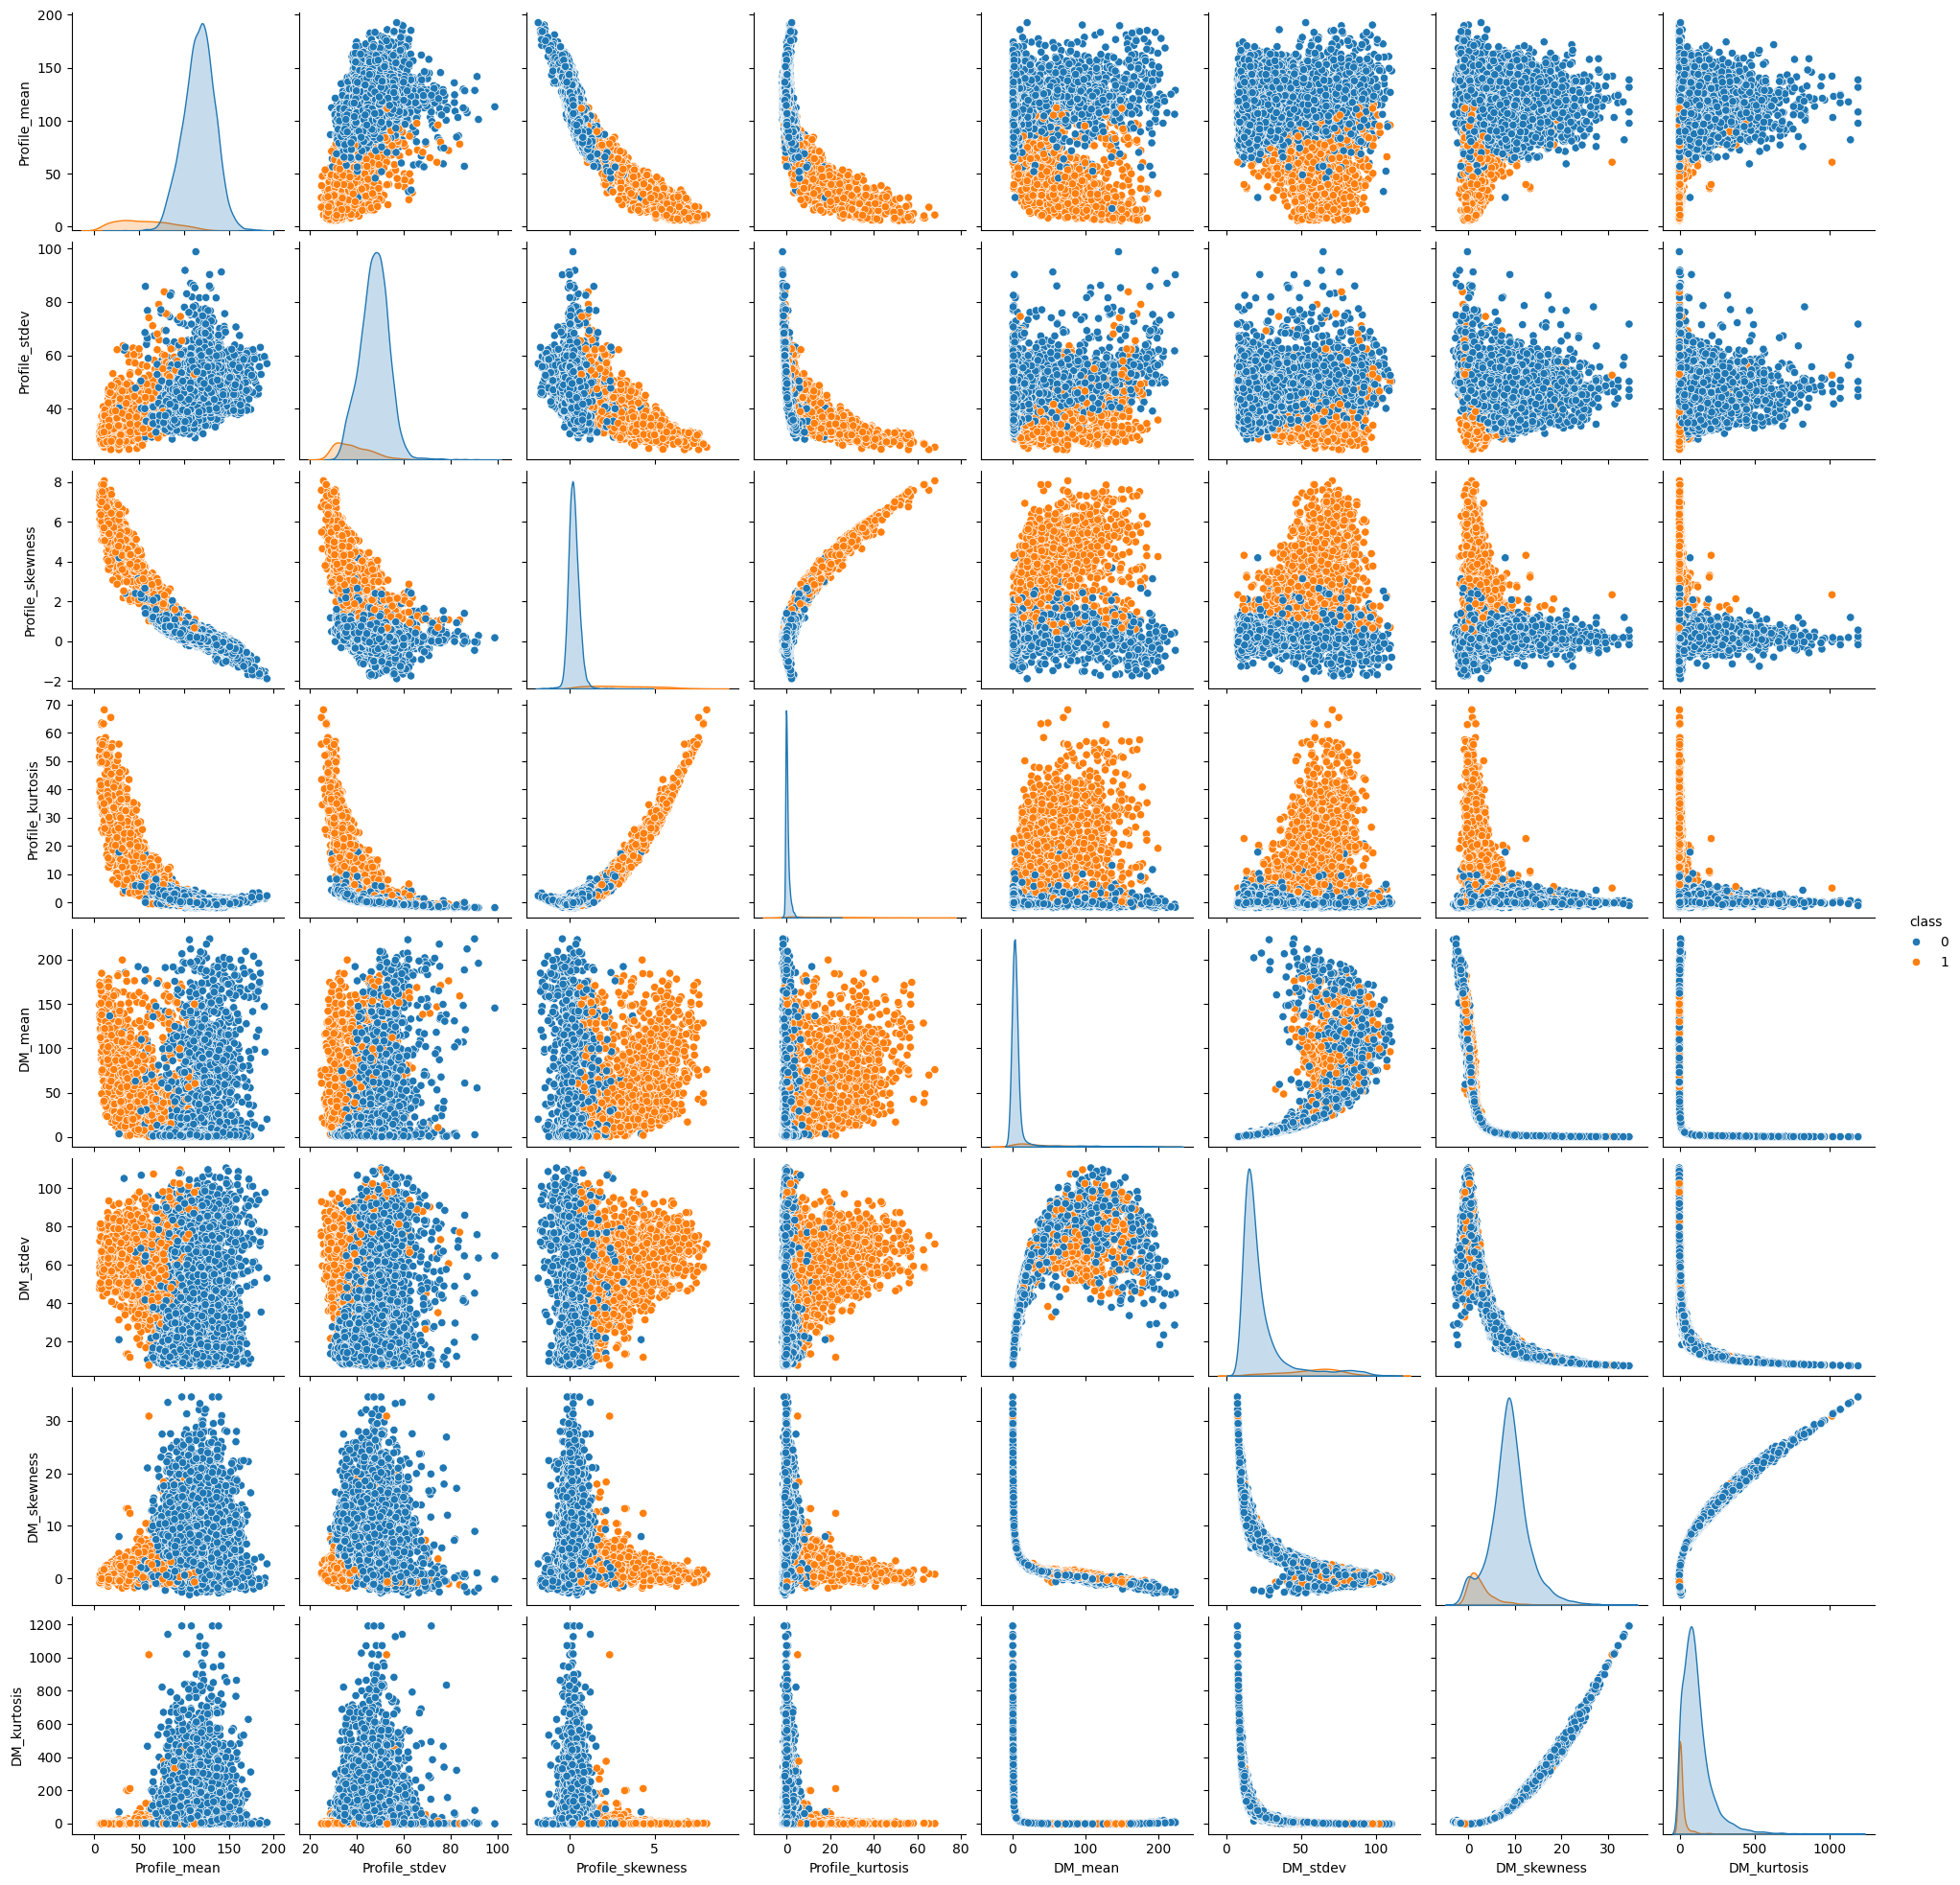

In [ ]:
# === Pairplot (muestra balanceada para visualización) ===

# Visualize the dataset
sns.pairplot(df_data, hue='class')

# Split Train %80 / Test %20

In [ ]:
# === 05. Split estratificado train/test 80/20 ===

X = df_data.drop(columns='class').values
y = df_data['class'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"Train: {len(y_train)} instances  ({y_train.mean()*100:.2f} % pulsars)")
print(f"Test:  {len(y_test)} instances  ({y_test.mean()*100:.2f} % pulsars)")

Train: 14318 instances  (9.16 % pulsars)
Test:  3580 instances  (9.16 % pulsars)


# Estandarización

In [ ]:
# === 06. Estandarización ===
# fit solo en train, transform en ambos (evitar data leakage)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Mean of X_train_scaled (should be ≈ 0):")
print(X_train_scaled.mean(axis=0).round(4))
print()
print("Std of X_train_scaled (should be ≈ 1):")
print(X_train_scaled.std(axis=0).round(4))

Mean of X_train_scaled (should be ≈ 0):
[-0.  0.  0.  0.  0. -0.  0.  0.]

Std of X_train_scaled (should be ≈ 1):
[1. 1. 1. 1. 1. 1. 1. 1.]


# Modelo 1: Regresión Logística, probando dos solvers

Probando: lbfgs y newton-cholesky para luego comparar

In [ ]:
# === 07. Modelo 1: Regresión Logística ===
# Probamos dos solvers: lbfgs y newton-cholesky
# class_weight='balanced' para compensar el desbalance

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_grid = {'C': [0.01, 0.1, 1.0, 10.0, 100.0]}

# Solver 1: lbfgs
lr_lbfgs = GridSearchCV(
    LogisticRegression(solver='lbfgs', class_weight='balanced',
                       max_iter=2000, random_state=42),
    lr_grid, cv=cv, scoring='f1', n_jobs=-1, return_train_score=True,
)
lr_lbfgs.fit(X_train_scaled, y_train)

print("=== Solver: lbfgs ===")
print("Best C:", lr_lbfgs.best_params_['C'])
print(f"Best F1 (CV): {lr_lbfgs.best_score_:.4f}")
print()

# Solver 2: newton-cholesky
lr_newton = GridSearchCV(
    LogisticRegression(solver='newton-cholesky', class_weight='balanced',
                       max_iter=2000, random_state=42),
    lr_grid, cv=cv, scoring='f1', n_jobs=-1, return_train_score=True,
)
lr_newton.fit(X_train_scaled, y_train)

print("=== Solver: newton-cholesky ===")
print("Best C:", lr_newton.best_params_['C'])
print(f"Best F1 (CV): {lr_newton.best_score_:.4f}")

=== Solver: lbfgs ===
Best C: 0.1
Best F1 (CV): 0.8486

=== Solver: newton-cholesky ===
Best C: 0.1
Best F1 (CV): 0.8486


In [ ]:
# === Comparación de solvers ===

print("Solver comparison:")
print(f"  lbfgs:            C = {lr_lbfgs.best_params_['C']:>6}  F1 = {lr_lbfgs.best_score_:.4f}")
print(f"  newton-cholesky:  C = {lr_newton.best_params_['C']:>6}  F1 = {lr_newton.best_score_:.4f}")
print()

# Seleccionar el mejor solver
if lr_newton.best_score_ >= lr_lbfgs.best_score_:
    lr_search = lr_newton
    print("Selected solver: newton-cholesky")
else:
    lr_search = lr_lbfgs
    print("Selected solver: lbfgs")

Solver comparison:
  lbfgs:            C =    0.1  F1 = 0.8486
  newton-cholesky:  C =    0.1  F1 = 0.8486

Selected solver: newton-cholesky


In [ ]:
# === Diagnóstico de overfitting (LR) ===

lr_results = pd.DataFrame(lr_search.cv_results_)[[
    'param_C', 'mean_train_score', 'mean_test_score', 'std_test_score'
]].rename(columns={
    'mean_train_score': 'F1 train',
    'mean_test_score':  'F1 val (CV)',
    'std_test_score':   'std val',
})
lr_results.round(4)

,param_C,F1 train,F1 val (CV),std val
0,0.01,0.8298,0.8298,0.0084
1,0.10,0.8478,0.8486,0.0103
2,1.00,0.8434,0.8413,0.0121
3,10.00,0.8401,0.8368,0.0116
4,100.00,0.8398,0.8377,0.0111


### Diagnóstico de overfitting (Logistic Regression)

La tabla muestra los resultados de GridSearchCV con validación cruzada estratificada de 5 folds para distintos valores del hiperparámetro C.

Las brechas entre F1 train y F1 validación son mínimas (< 1%) para todos los valores de C, lo que indica que el modelo **no presenta overfitting**. El mejor rendimiento se obtiene con `C = 0.10` (F1 val = 0.8486). Valores más bajos de C producen underfitting leve (modelo demasiado restrictivo), mientras que valores más altos no mejoran la generalización.

# Matriz de confusión LR (Train)

=== Logistic Regression (Train) ===
              precision    recall  f1-score   support

  Non-pulsar     0.9905    0.9771    0.9837     13007
      Pulsar     0.7996    0.9069    0.8499      1311

    accuracy                         0.9707     14318
   macro avg     0.8950    0.9420    0.9168     14318
weighted avg     0.9730    0.9707    0.9715     14318



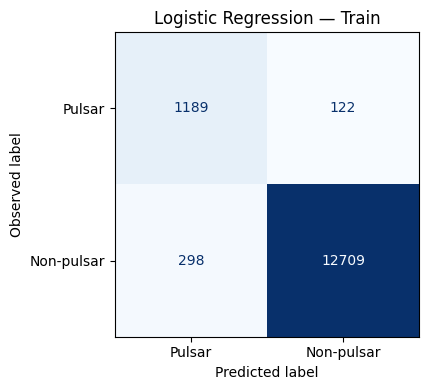

In [ ]:
# === Matriz de confusión: Regresión Logística (Train) ===
# Orden: Pulsar primero (como la imagen de referencia)

lr_best = lr_search.best_estimator_
y_train_pred_lr = lr_best.predict(X_train_scaled)

print("=== Logistic Regression (Train) ===")
print(classification_report(y_train, y_train_pred_lr,
      target_names=['Non-pulsar', 'Pulsar'], digits=4))

fig, ax = plt.subplots(figsize=(5, 4))
cm_lr_train = confusion_matrix(y_train, y_train_pred_lr, labels=[1, 0])
ConfusionMatrixDisplay(cm_lr_train, display_labels=['Pulsar', 'Non-pulsar']).plot(
    ax=ax, cmap='Blues', colorbar=False, values_format='d'
)
ax.set_xlabel('Predicted label')
ax.set_ylabel('Observed label')
ax.set_title('Logistic Regression — Train')
fig.tight_layout()
plt.show()

# Modelo 2: Random Forest



In [ ]:
# === 08. Modelo 2: Random Forest ===

rf_grid = {
    'n_estimators':     [50, 150],
    'max_depth':        [5, 15],
    'min_samples_leaf': [1, 5, 10],
}

rf_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42),
    rf_grid, cv=cv, scoring='f1', n_jobs=-1, return_train_score=True,
)
rf_search.fit(X_train_scaled, y_train)

print("Best hyperparameters:", rf_search.best_params_)
print(f"Best F1 (CV): {rf_search.best_score_:.4f}")

Best hyperparameters: {'max_depth': 15, 'min_samples_leaf': 1, 'n_estimators': 150}
Best F1 (CV): 0.8848


In [ ]:
# === Diagnóstico de overfitting (RF) ===

rf_cv_results = pd.DataFrame(rf_search.cv_results_)
cols = ['param_n_estimators', 'param_max_depth', 'param_min_samples_leaf',
        'mean_train_score', 'mean_test_score', 'std_test_score']
rf_cv_results.sort_values('mean_test_score', ascending=False)[cols].head(5).round(4)

,param_n_estimators,param_max_depth,param_min_samples_leaf,mean_train_score,mean_test_score,std_test_score
7,150,15,1,0.9955,0.8848,0.0156
6,50,15,1,0.9930,0.8826,0.0167
9,150,15,5,0.9312,0.8750,0.0121
8,50,15,5,0.9317,0.8740,0.0132
11,150,15,10,0.8954,0.8635,0.0085


### Diagnóstico de overfitting (Random Forest)

la mejor configuración (`n_estimators=150`, `max_depth=15`, `min_samples_leaf=1`) alcanza F1 train = 0.9955 y F1 validación = 0.8848, una **brecha del ~11%** que indica overfitting moderado. Sin embargo, las configuraciones con `min_samples_leaf=5` reducen el train score a ~0.93 y la brecha a ~6%, con F1 validación aún competitivo (0.8750). Con `min_samples_leaf=10`, el train score baja a 0.8954 y la brecha se reduce a ~3%, pero el F1 validación cae a 0.8635. El mejor compromiso entre rendimiento y generalización se encuentra en `min_samples_leaf=5`.



# Matriz de confusión RF (Train)

=== Random Forest (Train) ===
              precision    recall  f1-score   support

  Non-pulsar     0.9999    0.9987    0.9993     13007
      Pulsar     0.9872    0.9992    0.9932      1311

    accuracy                         0.9987     14318
   macro avg     0.9936    0.9990    0.9962     14318
weighted avg     0.9988    0.9987    0.9987     14318



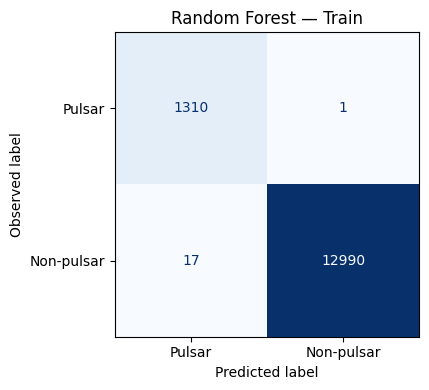

In [ ]:
# === Matriz de confusión: Random Forest (Train) ===

rf_best = rf_search.best_estimator_
y_train_pred_rf = rf_best.predict(X_train_scaled)

print("=== Random Forest (Train) ===")
print(classification_report(y_train, y_train_pred_rf,
      target_names=['Non-pulsar', 'Pulsar'], digits=4))

fig, ax = plt.subplots(figsize=(5, 4))
cm_rf_train = confusion_matrix(y_train, y_train_pred_rf, labels=[1, 0])
ConfusionMatrixDisplay(cm_rf_train, display_labels=['Pulsar', 'Non-pulsar']).plot(
    ax=ax, cmap='Blues', colorbar=False, values_format='d'
)
ax.set_xlabel('Predicted label')
ax.set_ylabel('Observed label')
ax.set_title('Random Forest — Train')
fig.tight_layout()
plt.show()

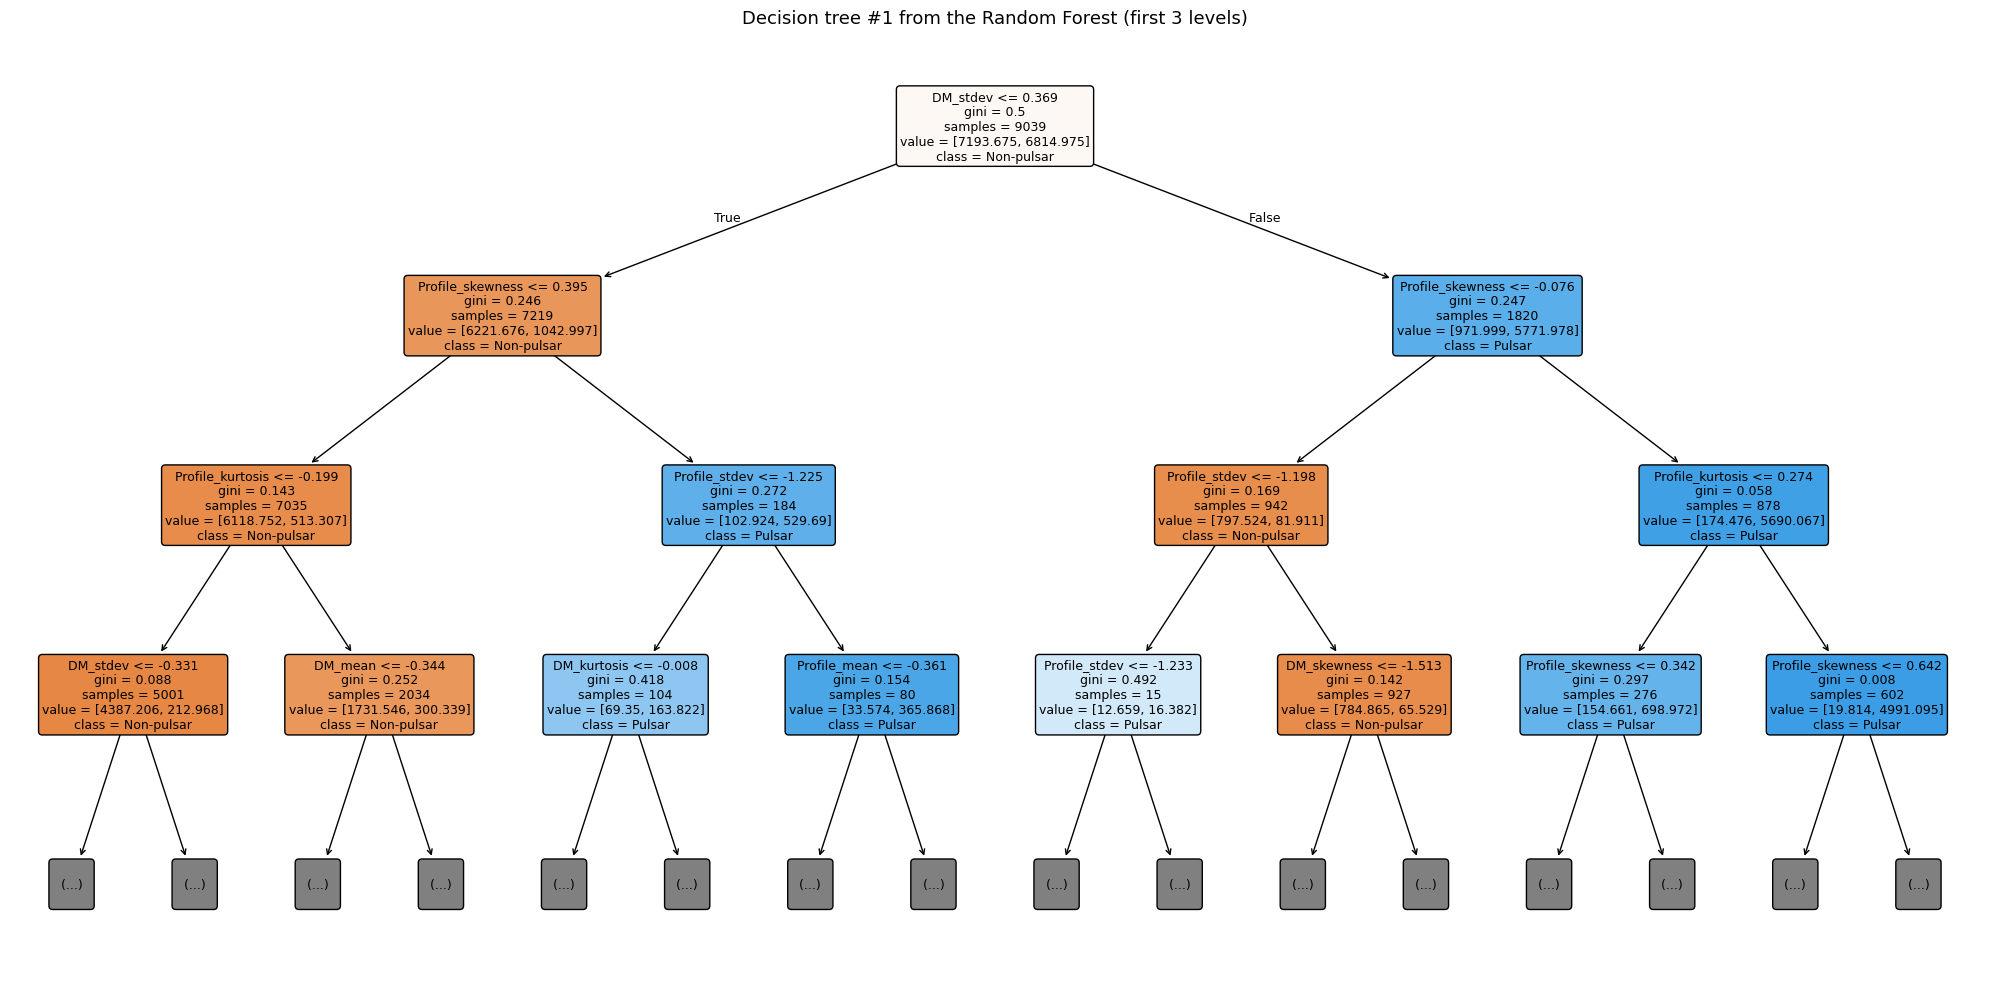

In [ ]:
# === Visualización de un árbol del Random Forest ===

from sklearn.tree import plot_tree

feature_names = [col for col in df_data.columns if col != 'class']

# Primer árbol del bosque (árbol 0 de 200)
# max_depth=3 para visualización (el árbol real es mucho más profundo)
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    rf_search.best_estimator_.estimators_[0],
    feature_names=feature_names,
    class_names=['Non-pulsar', 'Pulsar'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9,
    ax=ax
)
ax.set_title('Decision tree #1 from the Random Forest (first 3 levels)', fontsize=13)
fig.tight_layout()
plt.show()

# Modelo KNN

In [ ]:
# === 08b. Modelo 3: KNN ===

knn_grid = {
    'n_neighbors': [3, 5, 7, 11, 15, 21,100],
    'weights':     ['uniform', 'distance'],
}

knn_search = GridSearchCV(
    KNeighborsClassifier(),
    knn_grid, cv=cv, scoring='f1', n_jobs=-1, return_train_score=True,
)
knn_search.fit(X_train_scaled, y_train)

print("Best hyperparameters:", knn_search.best_params_)
print(f"Best F1 (CV): {knn_search.best_score_:.4f}")

Best hyperparameters: {'n_neighbors': 11, 'weights': 'distance'}
Best F1 (CV): 0.8722


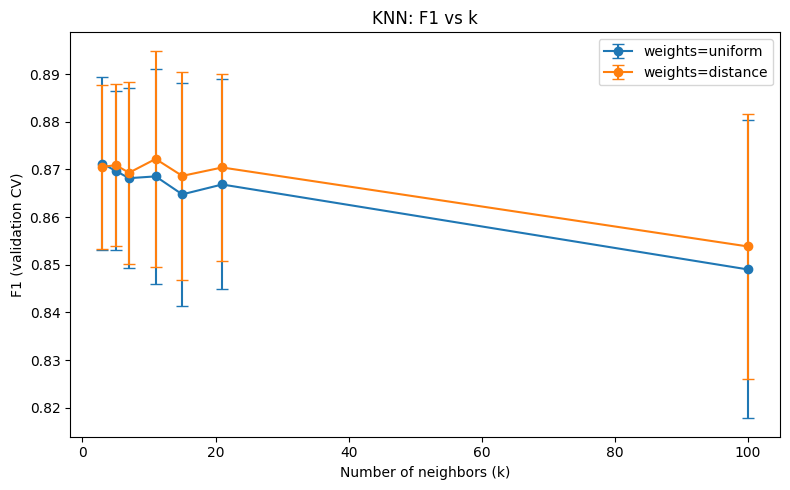

In [ ]:
# === Diagnóstico de KNN: F1 validación vs número de vecinos ===

knn_cv = pd.DataFrame(knn_search.cv_results_)

fig, ax = plt.subplots(figsize=(8, 5))

for w in ['uniform', 'distance']:
    mask = knn_cv['param_weights'] == w
    subset = knn_cv[mask].sort_values('param_n_neighbors')
    ax.errorbar(
        subset['param_n_neighbors'], subset['mean_test_score'],
        yerr=subset['std_test_score'], marker='o', capsize=4,
        label=f'weights={w}'
    )

ax.set_xlabel('Number of neighbors (k)')
ax.set_ylabel('F1 (validation CV)')
ax.set_title('KNN: F1 vs k')
ax.legend()
fig.tight_layout()
plt.show()

### Diagnóstico de KNN

El diagnóstico de KNN se realiza observando cómo varía el F1 en validación CV al cambiar $k$ . El F1 es estable para $k$ bajo (3–11, F1 ≈ 0.87) y decrece para $k$ alto (100, F1 ≈ 0.85), indicando underfitting leve con demasiados vecinos. El modelo no presenta overfitting significativo. El valor óptimo es $k = 11$ con `weights='distance'`.

# Modelo SVM

In [ ]:
# === 08c. Modelo 4: SVM (RBF) ===

svm_grid = {
    'C':     [0.1, 1.0, 10.0],
    'gamma': ['scale', 0.01, 0.1],
}

svm_search = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
    svm_grid, cv=cv, scoring='f1', n_jobs=-1, return_train_score=True,
)
svm_search.fit(X_train_scaled, y_train)

print("Best hyperparameters:", svm_search.best_params_)
print(f"Best F1 (CV): {svm_search.best_score_:.4f}")

Best hyperparameters: {'C': 1.0, 'gamma': 0.01}
Best F1 (CV): 0.8713


In [ ]:
# === Diagnóstico de overfitting (SVM) ===

svm_cv_results = pd.DataFrame(svm_search.cv_results_)
cols_svm = ['param_C', 'param_gamma',
            'mean_train_score', 'mean_test_score', 'std_test_score']
svm_cv_results.sort_values('mean_test_score', ascending=False)[cols_svm].head(5).round(4)

,param_C,param_gamma,mean_train_score,mean_test_score,std_test_score
4,1.0,0.01,0.8724,0.8713,0.0094
7,10.0,0.01,0.8667,0.8660,0.0065
6,10.0,scale,0.8748,0.8641,0.0120
8,10.0,0.1,0.8726,0.8622,0.0118
3,1.0,scale,0.8677,0.8618,0.0085


### Diagnóstico de overfitting (SVM RBF)

El SVM muestra **excelente generalización**: la brecha entre F1 train (0.8724) y F1 validación (0.8713) es de apenas 0.1% para la mejor configuración (`C=1.0`, `gamma=0.01`). El valor bajo de gamma indica fronteras de decisión suaves, lo que previene el sobreajuste. Aumentar C a 10.0 no mejora el rendimiento, confirmando que el modelo opera en su punto óptimo.

=== SVM RBF (Train) ===
              precision    recall  f1-score   support

  Non-pulsar     0.9899    0.9833    0.9866     13007
      Pulsar     0.8448    0.9008    0.8719      1311

    accuracy                         0.9758     14318
   macro avg     0.9174    0.9421    0.9293     14318
weighted avg     0.9766    0.9758    0.9761     14318



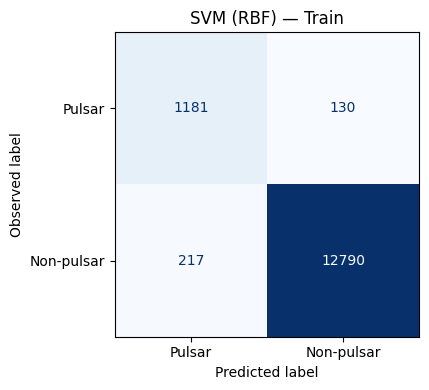

In [ ]:
# === Matriz de confusión: SVM (Train) ===

svm_best = svm_search.best_estimator_
y_train_pred_svm = svm_best.predict(X_train_scaled)

print("=== SVM RBF (Train) ===")
print(classification_report(y_train, y_train_pred_svm,
      target_names=['Non-pulsar', 'Pulsar'], digits=4))

fig, ax = plt.subplots(figsize=(5, 4))
cm_svm_train = confusion_matrix(y_train, y_train_pred_svm, labels=[1, 0])
ConfusionMatrixDisplay(cm_svm_train, display_labels=['Pulsar', 'Non-pulsar']).plot(
    ax=ax, cmap='Blues', colorbar=False, values_format='d'
)
ax.set_xlabel('Predicted label')
ax.set_ylabel('Observed label')
ax.set_title('SVM (RBF) — Train')
fig.tight_layout()
plt.show()

# Evaluación de los 4 modelos con TEST

In [ ]:
# === 09. Evaluación final: 4 modelos en test ===

all_models = {
    'Logistic Regression': lr_search.best_estimator_,
    'Random Forest':       rf_search.best_estimator_,
    'KNN':                 knn_search.best_estimator_,
    'SVM (RBF)':           svm_search.best_estimator_,
}

# Probabilidades y predicciones
all_proba = {n: m.predict_proba(X_test_scaled)[:, 1] for n, m in all_models.items()}
all_preds = {n: (p >= 0.5).astype(int) for n, p in all_proba.items()}

# Tabla resumen de métricas
rows = []
for name in all_models:
    p, yhat = all_proba[name], all_preds[name]
    rows.append({
        'Model':     name,
        'Precision': precision_score(y_test, yhat),
        'Recall':    recall_score(y_test, yhat),
        'F1':        f1_score(y_test, yhat),

    })
metrics_all = pd.DataFrame(rows).set_index('Model').round(4)
metrics_all

,Precision,Recall,F1
Model,,,
Logistic Regression,0.7942,0.9177,0.8515
Random Forest,0.9054,0.8750,0.8899
KNN,0.9392,0.8476,0.8910
SVM (RBF),0.9414,0.8323,0.8835


### Evaluación comparativa en test

Se observa un trade-off claro entre precision y recall: la **LR maximiza el recall** (0.9177, solo pierde 27 púlsares de 328) a costa de más falsos positivos, mientras que **SVM y KNN maximizan la precision** (>0.93, solo 17–18 falsos positivos) pero pierden más púlsares. RF y KNN ofrecen el mejor balance en F1 (~0.89).

# Matrices de confusión de los 4 modelos

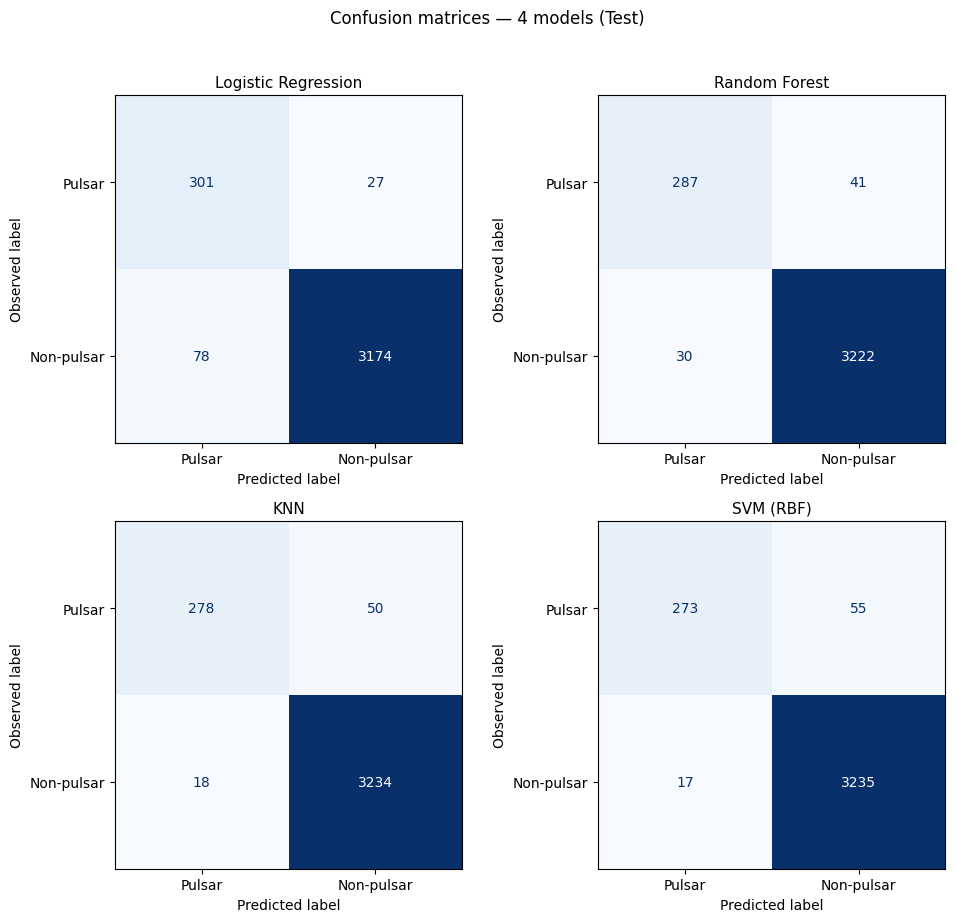

In [ ]:
# === Matrices de confusión: 4 modelos (2x2) ===

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, (name, m) in zip(axes.flat, all_models.items()):
    cm = confusion_matrix(y_test, all_preds[name], labels=[1, 0])
    ConfusionMatrixDisplay(cm, display_labels=['Pulsar', 'Non-pulsar']).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format='d'
    )
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('Observed label')
    ax.set_title(name, fontsize=11)
fig.suptitle('Confusion matrices — 4 models (Test)', y=1.02)
fig.tight_layout()
plt.show()

# importancia de features y análisis del umbral de decisión

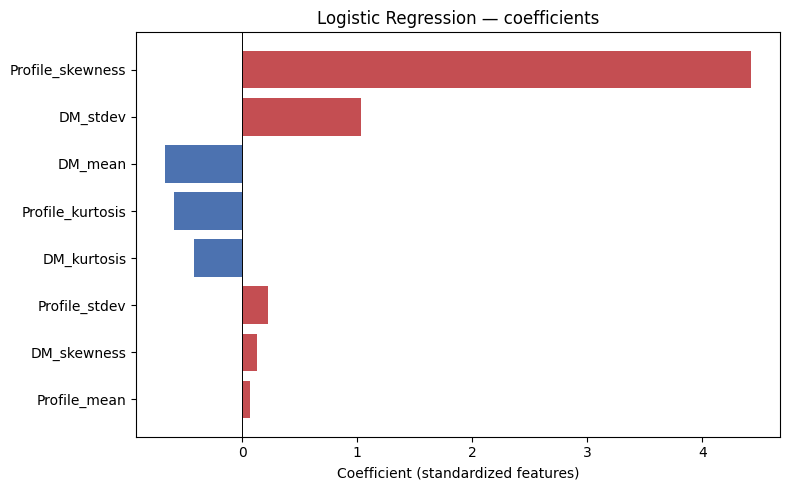

In [ ]:
# === 10. Feature importance: Logistic Regression coefficients ===

feature_names = [col for col in df_data.columns if col != 'class']

lr_best = lr_search.best_estimator_
lr_coefs = pd.Series(lr_best.coef_.ravel(), index=feature_names)

fig, ax = plt.subplots(figsize=(8, 5))
order = lr_coefs.abs().sort_values(ascending=True).index
colors = ['#C44E52' if v > 0 else '#4C72B0' for v in lr_coefs.loc[order]]
ax.barh(range(len(order)), lr_coefs.loc[order].values, color=colors)
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.axvline(0, color='k', lw=0.7)
ax.set_xlabel('Coefficient (standardized features)')
ax.set_title('Logistic Regression — coefficients')
fig.tight_layout()
plt.show()

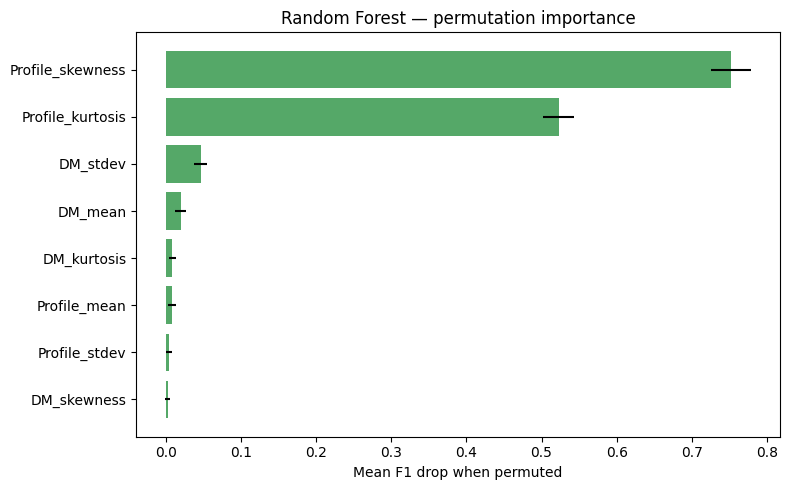

In [ ]:
# === 10b. Feature importance: Random Forest permutation importance ===

from sklearn.inspection import permutation_importance

rf_best = rf_search.best_estimator_

perm = permutation_importance(
    rf_best, X_test_scaled, y_test,
    n_repeats=20, random_state=42, n_jobs=-1,
    scoring='f1',
)
rf_perm = pd.Series(perm.importances_mean, index=feature_names)
rf_perm_std = pd.Series(perm.importances_std, index=feature_names)

fig, ax = plt.subplots(figsize=(8, 5))
order2 = rf_perm.sort_values(ascending=True).index
ax.barh(range(len(order2)), rf_perm.loc[order2].values,
        xerr=rf_perm_std.loc[order2].values, color='#55A868', ecolor='k')
ax.set_yticks(range(len(order2)))
ax.set_yticklabels(order2)
ax.set_xlabel('Mean F1 drop when permuted')
ax.set_title('Random Forest — permutation importance')
fig.tight_layout()
plt.show()

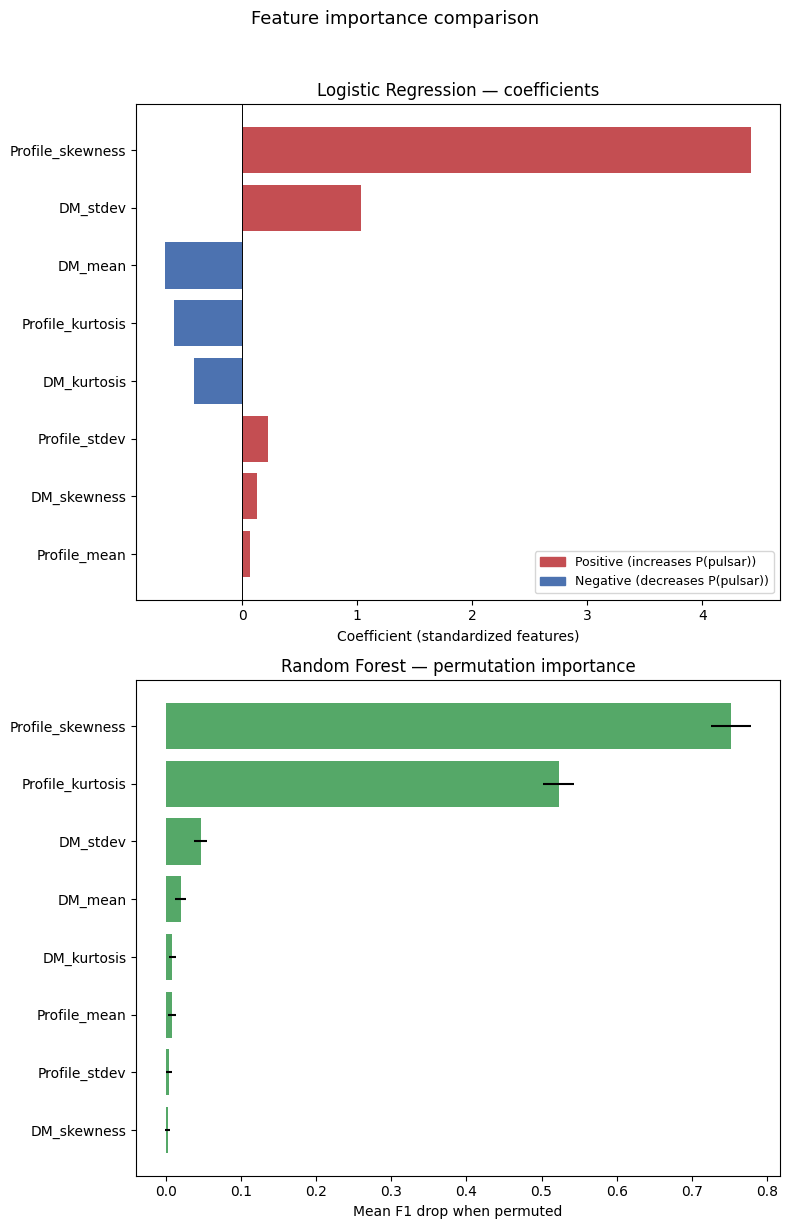

In [ ]:
# === 10c. Comparación lado a lado ===

from matplotlib.patches import Patch

fig, axes = plt.subplots(2, 1, figsize=(8, 12))

# LR
ax = axes[0]
order = lr_coefs.abs().sort_values(ascending=True).index
colors = ['#C44E52' if v > 0 else '#4C72B0' for v in lr_coefs.loc[order]]
ax.barh(range(len(order)), lr_coefs.loc[order].values, color=colors)
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.axvline(0, color='k', lw=0.7)
ax.set_xlabel('Coefficient (standardized features)')
ax.set_title('Logistic Regression — coefficients')
ax.legend(handles=[
    Patch(color='#C44E52', label='Positive (increases P(pulsar))'),
    Patch(color='#4C72B0', label='Negative (decreases P(pulsar))'),
], loc='lower right', fontsize=9)

# RF
ax = axes[1]
order2 = rf_perm.sort_values(ascending=True).index
ax.barh(range(len(order2)), rf_perm.loc[order2].values,
        xerr=rf_perm_std.loc[order2].values, color='#55A868', ecolor='k')
ax.set_yticks(range(len(order2)))
ax.set_yticklabels(order2)
ax.set_xlabel('Mean F1 drop when permuted')
ax.set_title('Random Forest — permutation importance')

fig.suptitle('Feature importance comparison', y=1.02, fontsize=13)
fig.tight_layout()
plt.show()